# RF + SMOTE

In [1]:
# Imports principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [9]:
df = pd.read_csv("..\\datasets_paralelos\\kmeans_5clusters.csv")

In [10]:
# 2. Separar X e y
X = df.drop(columns=['cluster'])
Y = df['cluster']

In [11]:
# 3. Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

In [12]:
# 4. Definir o pipeline com SMOTE + RandomForest
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight=None,
        random_state=42
    ))
])

In [13]:
# 5. Cross-validation com pipeline
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Acurácias de cross-validation:", cv_scores)
print("Média da acurácia de cross-validation:", np.mean(cv_scores))

Acurácias de cross-validation: [0.97216368 0.97067088 0.97418335 0.97242712 0.97207587]
Média da acurácia de cross-validation: 0.9723041798384265


In [14]:
# 6. Treinar o pipeline completo no treino
pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('clf',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=2,
                                        min_samples_split=10, n_estimators=150,
                                        random_state=42))])

In [15]:
# 7. Avaliar no treino
y_train_pred = pipeline.predict(X_train)
print('Métricas de Classificação para o conjunto de treino:')
print(classification_report(y_train, y_train_pred))

Métricas de Classificação para o conjunto de treino:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     16691
           1       0.99      1.00      0.99      4629
           2       0.99      0.99      0.99     13014
           3       0.98      0.99      0.98     15504
           4       0.99      1.00      0.99      7102

    accuracy                           0.99     56940
   macro avg       0.99      0.99      0.99     56940
weighted avg       0.99      0.99      0.99     56940



In [16]:
# 8. Avaliar no teste
y_test_pred = pipeline.predict(X_test)
print("Métricas de Classificação para o conjunto de teste:")
print(classification_report(y_test, y_test_pred))

Métricas de Classificação para o conjunto de teste:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      7153
           1       0.97      0.99      0.98      1984
           2       0.97      0.98      0.98      5578
           3       0.97      0.98      0.97      6645
           4       0.98      0.99      0.98      3043

    accuracy                           0.97     24403
   macro avg       0.97      0.98      0.98     24403
weighted avg       0.97      0.97      0.97     24403



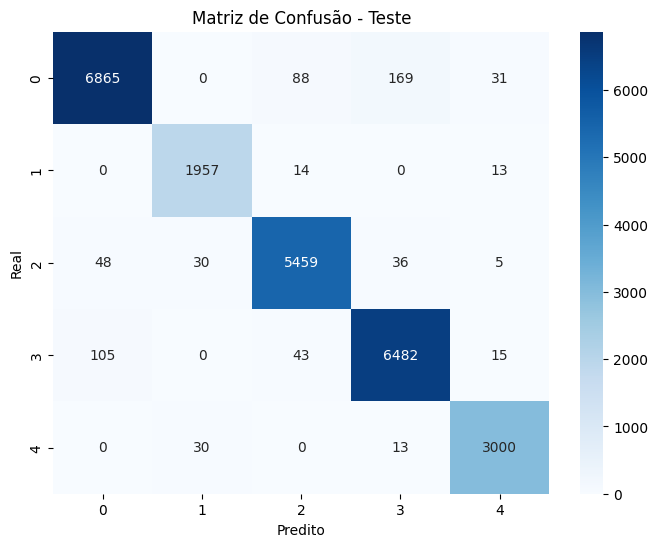

In [17]:
# 9. Matriz de confusão do teste
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(Y.unique()), yticklabels=sorted(Y.unique()))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Teste')
plt.show()

Matriz de Confusão para o conjunto de treino:
[[16244     0   115   277    55]
 [    0  4619     4     0     6]
 [   37    36 12900    37     4]
 [  153     0    47 15282    22]
 [    2    10     1    14  7075]]


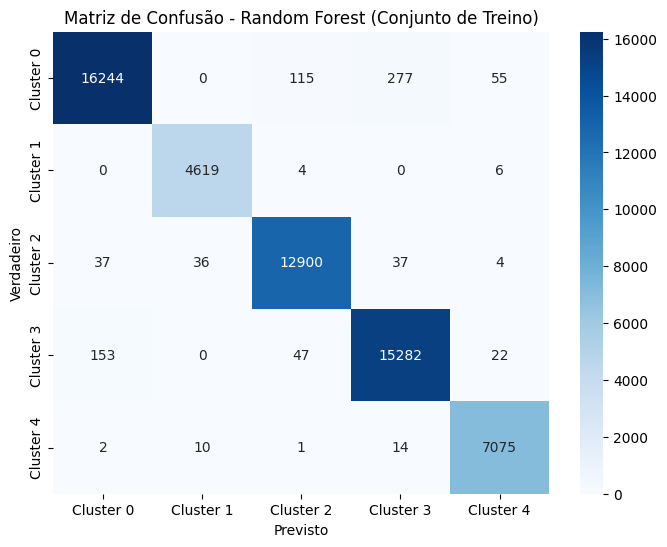

In [18]:

# Matriz de Confusão para o conjunto de treino
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
print("Matriz de Confusão para o conjunto de treino:")
print(conf_matrix_train)

# Criar os rótulos para os clusters
cluster_labels = [f'Cluster {i}' for i in range(5)]  # Se os clusters forem 0 a 4

# Plotar a matriz de confusão para o conjunto de treino
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=cluster_labels, yticklabels=cluster_labels)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Random Forest (Conjunto de Treino)')
plt.show()

